### 1. Dataset & Text Processing

### Unicode normalization

In [1]:
import unicodedata
import re

def unicode_to_ascii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

### Sentence cleaning function

In [2]:
def clean_sentence(sentence):
    sentence = unicode_to_ascii(sentence.lower().strip())

    # Add space before punctuation
    sentence = re.sub(r"([.!?])", r" \1", sentence)

    # Keep only letters and punctuation
    sentence = re.sub(r"[^a-zA-Z.!?]+", r" ", sentence)

    # Remove extra spaces
    sentence = re.sub(r"\s+", " ", sentence).strip()

    return sentence


### Load and clean the dataset

In [5]:
def load_and_clean_data(file_path, max_samples=10000):
    pairs = []

    with open(file_path, encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= max_samples:
                break

            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue

            eng, fra = parts[0], parts[1]
            eng = clean_sentence(eng)
            fra = clean_sentence(fra)

            pairs.append((eng, fra))

    return pairs


### Check

In [6]:
data = load_and_clean_data("eng-fra.txt")
for i in range(5):
   print(data[i])

('go .', 'va !')
('go .', 'marche .')
('go .', 'en route !')
('go .', 'bouge !')
('hi .', 'salut !')


### 2. Tokenization

In [7]:
def tokenize_sentence(sentence):
    return sentence.split()


### Tokenize sentence pairs

In [8]:
def tokenize_pairs(pairs):
    tokenized_pairs = []

    for eng, fra in pairs:
        eng_tokens = eng.split()
        fra_tokens = ["<sos>"] + fra.split() + ["<eos>"]

        tokenized_pairs.append((eng_tokens, fra_tokens))

    return tokenized_pairs


### Test tokenization

In [9]:
data = load_and_clean_data("eng-fra.txt", max_samples=5)
tokenized = tokenize_pairs(data)

for pair in tokenized:
        print(pair)

(['go', '.'], ['<sos>', 'va', '!', '<eos>'])
(['go', '.'], ['<sos>', 'marche', '.', '<eos>'])
(['go', '.'], ['<sos>', 'en', 'route', '!', '<eos>'])
(['go', '.'], ['<sos>', 'bouge', '!', '<eos>'])
(['hi', '.'], ['<sos>', 'salut', '!', '<eos>'])


### 3. Vocabulary Building

In [20]:
from collections import Counter

class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq

        self.word2idx = {
            "<pad>": 0,
            "<sos>": 1,
            "<eos>": 2,
            "<unk>": 3
        }

        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
        self.word_freq = Counter()
    
    def build_vocab(self, sentences):
        for sentence in sentences:
            for word in sentence:
                self.word_freq[word] += 1

        for word, freq in self.word_freq.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    ### Convert tokens → indices
    def numericalize(self, sentence):
        return [
            self.word2idx.get(word, self.word2idx["<unk>"])
            for word in sentence
        ]

### Build vocabularies (source & target)

In [21]:
def build_vocabularies(tokenized_pairs):
    src_vocab = Vocabulary()
    trg_vocab = Vocabulary()

    src_sentences = [pair[0] for pair in tokenized_pairs]
    trg_sentences = [pair[1] for pair in tokenized_pairs]

    src_vocab.build_vocab(src_sentences)
    trg_vocab.build_vocab(trg_sentences)

    return src_vocab, trg_vocab


### Test vocabulary

In [22]:
data = load_and_clean_data("eng-fra.txt", max_samples=1000)
tokenized = tokenize_pairs(data)

src_vocab, trg_vocab = build_vocabularies(tokenized)

print("Source vocab size:", len(src_vocab.word2idx))
print("Target vocab size:", len(trg_vocab.word2idx))

print(src_vocab.word2idx["go"])
print(trg_vocab.word2idx["<sos>"])

Source vocab size: 216
Target vocab size: 300
4
1


### 4. Convert Sentences → Tensors

#### Numericalize sentence pairs

In [23]:
def numericalize_pairs(tokenized_pairs, src_vocab, trg_vocab):
    numericalized = []

    for src_tokens, trg_tokens in tokenized_pairs:
        src_indices = src_vocab.numericalize(src_tokens)
        trg_indices = trg_vocab.numericalize(trg_tokens)

        numericalized.append((src_indices, trg_indices))

    return numericalized


### Create DataLoader

In [24]:
from torch.utils.data import DataLoader
from dataset import TranslationDataset, collate_fn

# Load & process
pairs = load_and_clean_data("eng-fra.txt", max_samples=5000)
tokenized = tokenize_pairs(pairs)

src_vocab, trg_vocab = build_vocabularies(tokenized)
numericalized = numericalize_pairs(tokenized, src_vocab, trg_vocab)

dataset = TranslationDataset(numericalized)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)


### Check

In [25]:
for src, trg in loader:
    print(src.shape)
    print(trg.shape)
    print(src[:, 0])   # first sentence in batch
    print(trg[:, 0])
    break


torch.Size([4, 32])
torch.Size([9, 32])
tensor([ 61, 765,   6,   5])
tensor([   1,  143,  135, 1051,  115,    7,    2,    0,    0])


### 5. Baseline Seq2Seq

##### i. Encoder Network

In [ ]:
INPUT_DIM  = len(src_vocab.word2idx)
EMBED_DIM  = 256
HIDDEN_DIM = 512

In [29]:
from encoder_file import Encoder

encoder = Encoder(
    input_dim=len(src_vocab.word2idx),
    embed_dim=256,
    hidden_dim=512
)

for src, trg in loader:
    outputs, hidden = encoder(src)
    print(outputs.shape)
    print(hidden.shape)
    break


torch.Size([4, 32, 512])
torch.Size([1, 32, 512])


ii. Decoder Network

In [30]:
from decoder_file import Decoder

decoder = Decoder(
    output_dim=len(trg_vocab.word2idx),
    embed_dim=256,
    hidden_dim=512
)

for src, trg in loader:
    _, hidden = encoder(src)

    input_token = trg[0]  # <sos> tokens for batch
    output, hidden = decoder(input_token, hidden)

    print(output.shape)
    print(hidden.shape)
    break


torch.Size([32, 1090])
torch.Size([1, 32, 512])


iii. Seq2Seq Wrapper + Teacher Forcing

In [31]:
from seq2seq import Seq2Seq
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seq2seq = Seq2Seq(encoder, decoder, device).to(device)

for src, trg in loader:
    src = src.to(device)
    trg = trg.to(device)

    outputs = seq2seq(src, trg)
    print(outputs.shape)
    break


torch.Size([8, 32, 1090])


### Training Loop (Baseline)

i. Loss, Optimizer, and One Training Epoch

In [32]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.word2idx["<pad>"])
optimizer = optim.Adam(seq2seq.parameters(), lr=1e-3)


In [33]:
def train_one_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0

    for src, trg in loader:
        src = src.to(model.device)
        trg = trg.to(model.device)

        optimizer.zero_grad()

        output = model(src, trg)
        # output: (trg_len, batch_size, vocab_size)

        output_dim = output.shape[-1]

        output = output[1:].view(-1, output_dim)
        trg = trg[1:].reshape(-1)

        loss = criterion(output, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


In [34]:
output = output[1:]
trg = trg[1:]


In [36]:
N_EPOCHS = 5

for epoch in range(N_EPOCHS):
    loss = train_one_epoch(seq2seq, loader, optimizer, criterion)
    print(f"Epoch {epoch+1} | Loss: {loss:.3f}")


Epoch 1 | Loss: 3.246
Epoch 2 | Loss: 2.246
Epoch 3 | Loss: 1.709
Epoch 4 | Loss: 1.364
Epoch 5 | Loss: 1.106


# Attention Mechanism

In [37]:
from attention import BahdanauAttention

attention = BahdanauAttention(hidden_dim=512)

encoder_outputs, hidden = encoder(src)
decoder_hidden = hidden[-1]

context, attn_weights = attention(decoder_hidden, encoder_outputs)

print(context.shape)
print(attn_weights.shape)


torch.Size([32, 512])
torch.Size([32, 5])


##### Attention Decoder implementation

In [39]:
from attn_decoder import AttentionDecoder
from attention import BahdanauAttention

attention = BahdanauAttention(hidden_dim=512)

decoder = AttentionDecoder(
    output_dim=len(trg_vocab.word2idx),
    embed_dim=256,
    hidden_dim=512,
    attention=attention
)

encoder_outputs, hidden = encoder(src)
input_token = trg[0]

output, hidden, attn_weights = decoder(
    input_token, hidden, encoder_outputs
)

print(output.shape)
print(hidden.shape)
print(attn_weights.shape)


torch.Size([32, 1090])
torch.Size([1, 32, 512])
torch.Size([32, 5])


#### Attention-based Seq2Seq Wrapper

In [40]:
from attn_seq2seq import AttnSeq2Seq

model = AttnSeq2Seq(encoder, decoder, device).to(device)

for src, trg in loader:
    src = src.to(device)
    trg = trg.to(device)

    outputs, attentions = model(src, trg)
    print(outputs.shape)
    print(attentions.shape)
    break


torch.Size([9, 32, 1090])
torch.Size([9, 32, 5])


# Training Attention Model

In [41]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(
    ignore_index=trg_vocab.word2idx["<pad>"]
)

optimizer = optim.Adam(model.parameters(), lr=1e-3)


#### Training one epoch

In [42]:
def train_one_epoch_attn(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0

    for src, trg in loader:
        src = src.to(model.device)
        trg = trg.to(model.device)

        optimizer.zero_grad()

        outputs, _ = model(src, trg)
        # outputs: (trg_len, batch_size, vocab_size)

        output_dim = outputs.shape[-1]

        outputs = outputs[1:].view(-1, output_dim)
        trg = trg[1:].reshape(-1)

        loss = criterion(outputs, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


#### Run training

In [43]:
N_EPOCHS = 5

for epoch in range(N_EPOCHS):
    loss = train_one_epoch_attn(
        model, loader, optimizer, criterion
    )
    print(f"Epoch {epoch+1} | Attention Loss: {loss:.3f}")


Epoch 1 | Attention Loss: 2.649
Epoch 2 | Attention Loss: 1.463
Epoch 3 | Attention Loss: 1.207
Epoch 4 | Attention Loss: 1.070
Epoch 5 | Attention Loss: 0.976


# Inference (Translation)

In [46]:
from translate import translate_sentence

sentence = "hi ."

translation, attentions = translate_sentence(
    model,
    sentence,
    src_vocab,
    trg_vocab,
    device
)

print("Input:", sentence)
print("Output:", " ".join(translation))

  

Input: hi .
Output: salut les <unk> . <eos>


# BLEU Score Evaluation

In [ ]:
!pip install sacrebleu

  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
Using cached tabulate-0.9.0-py3-none-any.whl (35 kB)

   ---------------------------------------- 0/3 [tabulate]
   ------------- -------------------------- 1/3 [portalocker]
   -------------------------- ------------- 2/3 [sacrebleu]
   -------------------------- ------------- 2/3 [sacrebleu]
   -------------------------- ------------- 2/3 [sacrebleu]
   -------------------------- ------------- 2/3 [sacrebleu]
   -------------------------- ------------- 2/3 [sacrebleu]
   -------------------------- ------------- 2/3 [sacrebleu]
   ---------------------------------------- 3/3 [sacrebleu]




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
from bleu import calculate_bleu

bleu_score = calculate_bleu(
    model,
    loader,
    src_vocab,
    trg_vocab,
    device
)

print(f"BLEU score (Attention): {bleu_score:.2f}")


BLEU score (Attention): 22.96


# 

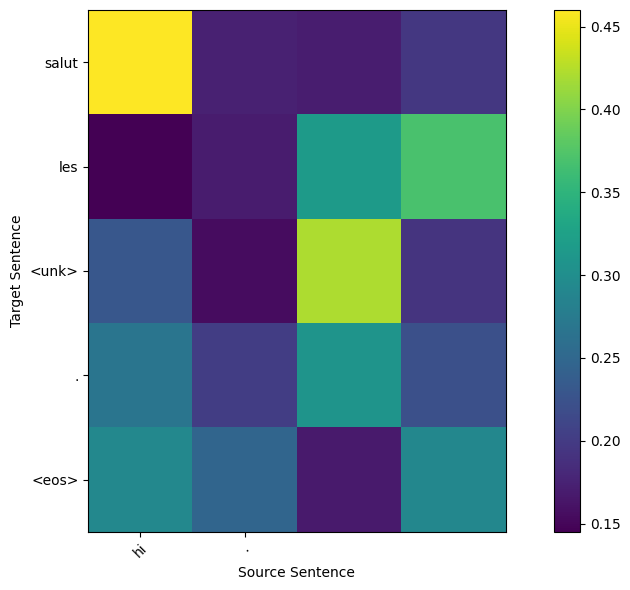

In [50]:
from visualize_attention import visualize_attention

sentence = "hi ."

translation, attentions = translate_sentence(
    model,
    sentence,
    src_vocab,
    trg_vocab,
    device
)

src_tokens = sentence.split()
trg_tokens = translation

visualize_attention(
    src_tokens,
    trg_tokens,
    attentions
)
